In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("daraz_sales.csv")

print(df.head(3)) 

  Order_ID     Customer_Name    Customer_City           Product_Name  \
0   O00001  Nicole Walsh PhD    South Melissa         Pro Headphones   
1   O00002     Vanessa Berry       Garciastad       Super Smartwatch   
2   O00003  Christina Kramer  Fergusonborough  Innovative Headphones   

      Category    Price  Quantity  Order_Date Delivery_Date    Payment_Method  \
0  Electronics  1513.75         4  2024-03-24    2024-03-28    Online Banking   
1        Books   903.48         1  2024-12-14    2024-12-24        Debit Card   
2        Books   582.08         3  2024-12-19    2024-12-20  Cash On Delivery   

  Order_Status    Seller_Name  
0      Pending   Turner Group  
1     Returned  Medina-Rivers  
2    Delivered  Martin-Harris  


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1400 non-null   str    
 1   Customer_Name   1400 non-null   str    
 2   Customer_City   1400 non-null   str    
 3   Product_Name    1400 non-null   str    
 4   Category        1400 non-null   str    
 5   Price           1400 non-null   float64
 6   Quantity        1400 non-null   int64  
 7   Order_Date      1400 non-null   str    
 8   Delivery_Date   1400 non-null   str    
 9   Payment_Method  1400 non-null   str    
 10  Order_Status    1400 non-null   str    
 11  Seller_Name     1400 non-null   str    
dtypes: float64(1), int64(1), str(10)
memory usage: 131.4 KB


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,1400.0,999.874286,573.796874,6.31,496.7775,1006.795,1513.3825,1996.62
Quantity,1400.0,2.950000,1.428421,1.00,2.0000,3.000,4.0000,5.00


In [6]:
df.shape

(1400, 12)

In [ ]:

df.columns

Index(['Order_ID', 'Customer_Name', 'Customer_City', 'Product_Name',
       'Category', 'Price', 'Quantity', 'Order_Date', 'Delivery_Date',
       'Payment_Method', 'Order_Status', 'Seller_Name'],
      dtype='str')

In [15]:
df.dtypes

Order_ID              str
Customer_Name         str
Customer_City         str
Product_Name          str
Category              str
Price             float64
Quantity            int64
Order_Date            str
Delivery_Date         str
Payment_Method        str
Order_Status          str
Seller_Name           str
dtype: object

In [16]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage (%)
Order_ID,0,0.0
Customer_Name,0,0.0
Customer_City,0,0.0
Product_Name,0,0.0
Category,0,0.0
Price,0,0.0
Quantity,0,0.0
Order_Date,0,0.0
Delivery_Date,0,0.0
Payment_Method,0,0.0


In [17]:
duplicate_summary = pd.DataFrame({
    "Metric": ["Duplicate Rows"],
    "Count": [df.duplicated().sum()]
})

duplicate_summary

,Metric,Count
0,Duplicate Rows,0


In [27]:
#DATE IS AN STR WE CONVERT IT INTO DATE DTYPE

df["Order_Date"]=pd.to_datetime(df["Order_Date"])
df['Delivery_Date']=pd.to_datetime(df['Delivery_Date'])

In [25]:
df["Customer_City"] = df["Customer_City"].str.strip()

df["Seller_Name"] = df["Seller_Name"].str.strip()

df["Customer_Name"] = df["Customer_Name"].str.upper()

In [29]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df["Price"] >= lower) &
        (df["Price"] <= upper)]

In [ ]:
df["Customer_City"].unique()

<StringArray>
[   'South Melissa',       'Garciastad',  'Fergusonborough',
       'Thomasport',      'Timothystad',         'Adamtown',
      'South Tracy',         'Saraview',       'Meganshire',
        'West Rita',
 ...
 'West Nathanville',     'North Tracey',  'North Christina',
      'East Kaylee',  'Lake Melvinfurt',  'North Paulburgh',
         'Kentview',      'Stevenhaven',   'Lake Aaronside',
    'West Michelle']
Length: 1334, dtype: str

In [33]:
df["Payment_Method"].unique()

<StringArray>
['Online Banking', 'Debit Card', 'Cash On Delivery', 'Credit Card']
Length: 4, dtype: str

In [34]:
df["Category"].unique()

<StringArray>
[    'Electronics',           'Books', 'Home Appliances',      'Automotive',
         'Fashion',          'Beauty',          'Sports']
Length: 7, dtype: str

# Exploratory Data Analysis 

In [36]:
df["sales"] = df["Quantity"] * df["Price"]

In [37]:
df["order_year"] = df["Order_Date"].dt.year

In [38]:
df["order_month"] = df["Order_Date"].dt.month_name()

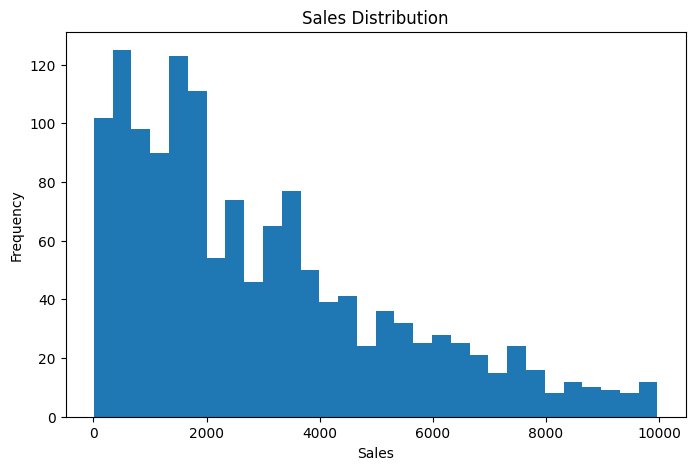

In [39]:
plt.figure(figsize=(8,5))
plt.hist(df["sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

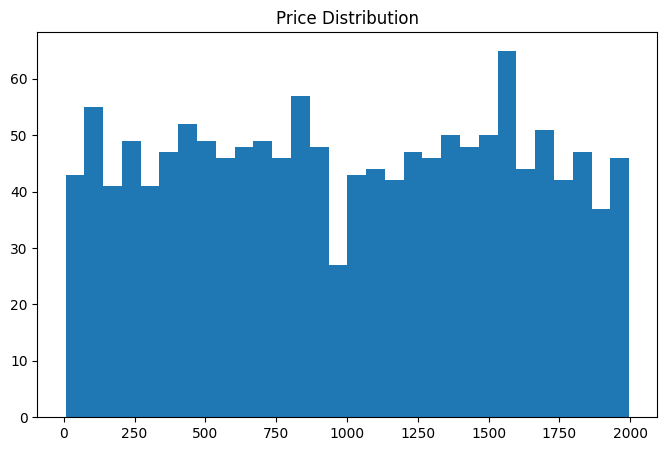

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=30)
plt.title("Price Distribution")
plt.show()

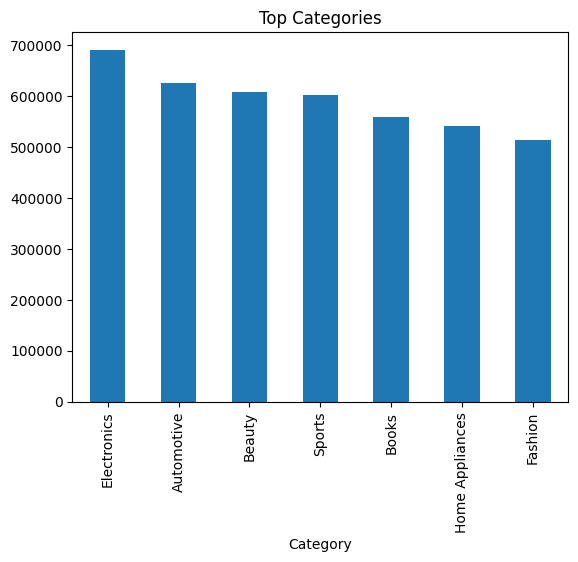

In [ ]:
top_category = (
    df.groupby("Category")["sales"]
      .sum()
      .sort_values(ascending=False)
      
      
)

top_category.plot(kind="bar")
plt.title("Top Categories")
plt.show()

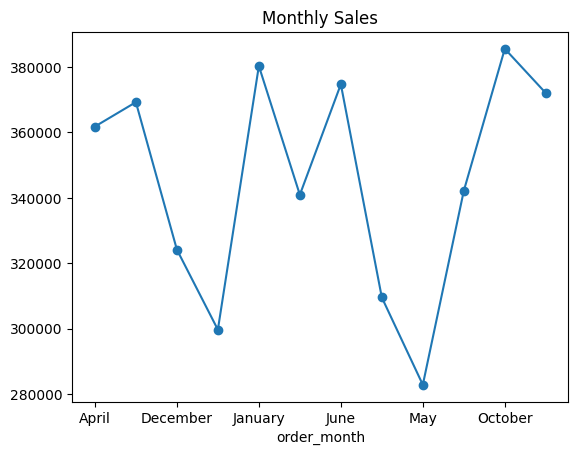

In [43]:
monthly_sales = (
    df.groupby("order_month")["sales"]
      .sum()
)

monthly_sales.plot(marker="o")
plt.title("Monthly Sales")
plt.show()

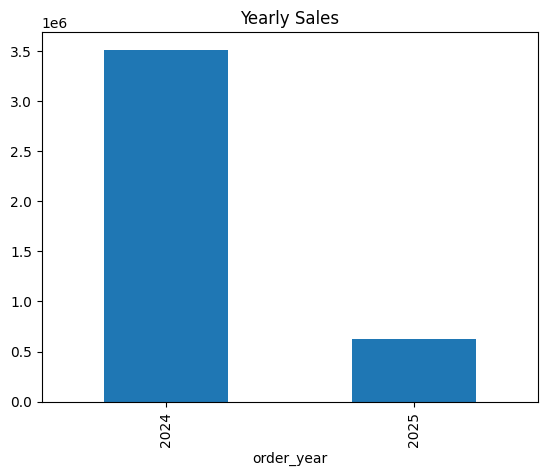

In [44]:
yearly_sales = (
    df.groupby("order_year")["sales"]
      .sum()
)

yearly_sales.plot(kind="bar")
plt.title("Yearly Sales")
plt.show()

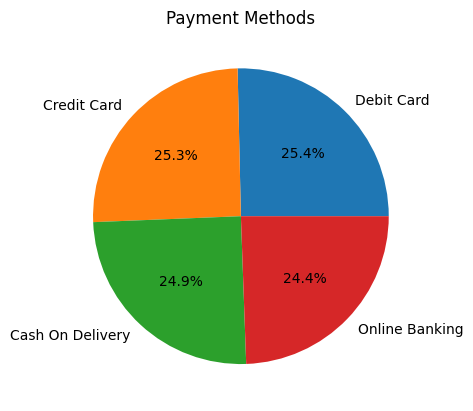

In [46]:
payment = df["Payment_Method"].value_counts()

payment.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Payment Methods")
plt.show()

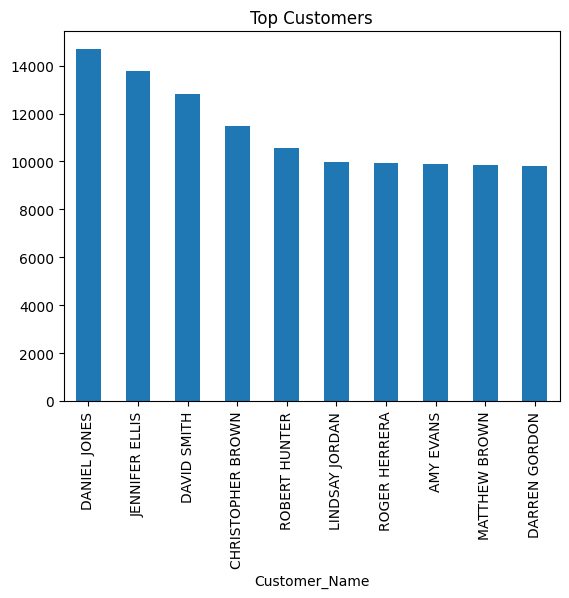

In [49]:
top_customers = (
    df.groupby("Customer_Name")["sales"]
      .sum()
      .nlargest(10)
)

top_customers.plot(kind="bar")
plt.title("Top Customers")
plt.show()

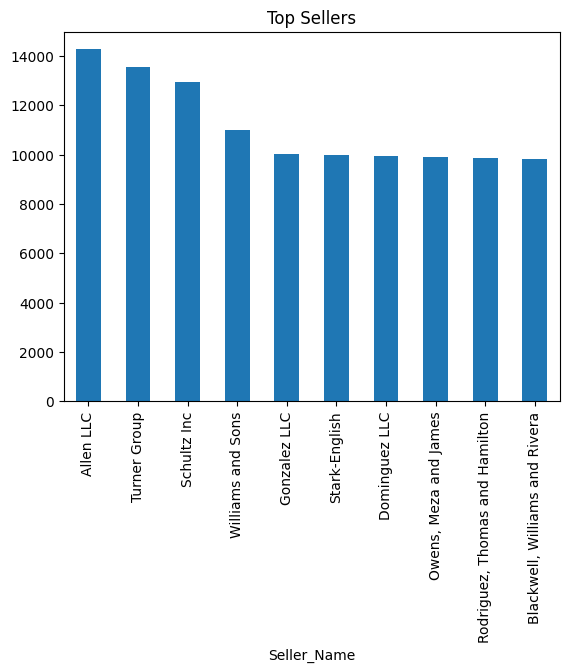

In [50]:
top_sellers = (
    df.groupby("Seller_Name")["sales"]
      .sum()
      .nlargest(10)
)

top_sellers.plot(kind="bar")
plt.title("Top Sellers")
plt.show()

In [51]:
df.to_csv("daraz_clean_dataset.csv", index=False)